In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
path = "C:/Users/LAPTOP/Downloads/FuelConsumptionCo2.csv"
file = pd.read_csv(path)

In [5]:
file.sample(7)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
619,2014,KIA,RONDO,STATION WAGON - MID-SIZE,2.0,4,M6,X,10.8,7.4,9.3,30,214
649,2014,LAND ROVER,RANGE ROVER V6 3.0 SC,SUV - STANDARD,3.0,6,AS8,Z,14.1,10.1,12.3,23,283
674,2014,LEXUS,RX 350 AWD,SUV - SMALL,3.5,6,AS6,X,13.3,9.8,11.7,24,269
763,2014,MERCEDES-BENZ,ML 350 4MATIC FFV,SUV - STANDARD,3.5,6,AS7,E,17.8,13.8,16.0,18,256
202,2014,CHEVROLET,CRUZE ECO,MID-SIZE,1.4,4,A6,X,9.1,6.0,7.7,37,177
303,2014,DODGE,CHARGER,FULL-SIZE,3.6,6,A8,X,12.4,7.7,10.3,27,237
901,2014,PORSCHE,PANAMERA,FULL-SIZE,3.6,6,AM7,Z,12.9,8.4,10.9,26,251


In [6]:
file = file.drop(["MODELYEAR", "MAKE", "MODEL", "VEHICLECLASS", "TRANSMISSION", "FUELTYPE"], axis=1)

In [7]:
file.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [8]:
file = file.drop(["CYLINDERS", "FUELCONSUMPTION_CITY", "FUELCONSUMPTION_HWY", "FUELCONSUMPTION_COMB"], axis=1)

In [9]:
file.sample(5)

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
1021,2.0,30,214
289,3.6,20,222
482,2.4,35,186
251,1.4,35,184
415,2.0,51,126


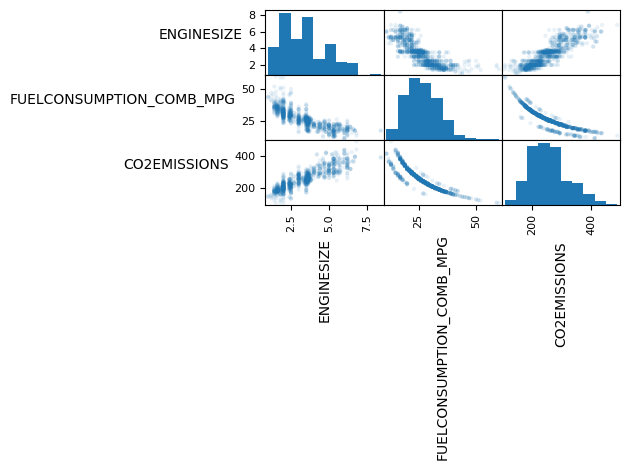

In [10]:
axes = pd.plotting.scatter_matrix(file, alpha=0.1)
for axs in axes.flatten():
    axs.yaxis.label.set_rotation(0)
    axs.xaxis.label.set_rotation(90)
    axs.yaxis.label.set_ha("right")

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

In [11]:
#manager = plt._pylab_helpers.Gcf.get_active()
#def get_figure(manager):
#    if manager is not None:
#        return manager.canvas.figure
#    else:
#        return figure()

In [12]:
X = file.iloc[:, [0,1]].to_numpy()
Y = file.iloc[:, [2]].to_numpy()

In [13]:
pd.DataFrame(X).describe().round(2)

,0,1
count,1067.00,1067.00
mean,3.35,26.44
std,1.42,7.47
min,1.00,11.00
25%,2.00,21.00
50%,3.40,26.00
75%,4.30,31.00
max,8.40,60.00


In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaler = scaler.fit_transform(X)

In [25]:
pd.DataFrame(x_scaler).describe().round(2)


,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x_scaler, Y, test_size=0.2, random_state=69)

In [44]:
from sklearn import linear_model 

regressor = linear_model.LinearRegression()

regressor.fit(X_train, Y_train)

coef_ = regressor.coef_
intercept_ = regressor.intercept_
print("coefficient: ",coef_)
print("intercept: ",intercept_)

coefficient:  [[ 25.97350528 -36.74545779]]
intercept:  [256.32621449]


In [45]:
means_ = scaler.mean_
x_std = np.sqrt(scaler.var_)
coef_original = coef_ / x_std
intercept_original = intercept_ - np.sum((means_ * coef_) / x_std)
print(coef_original)
print(intercept_original)


[[18.35283279 -4.92223267]]
[325.06301011]


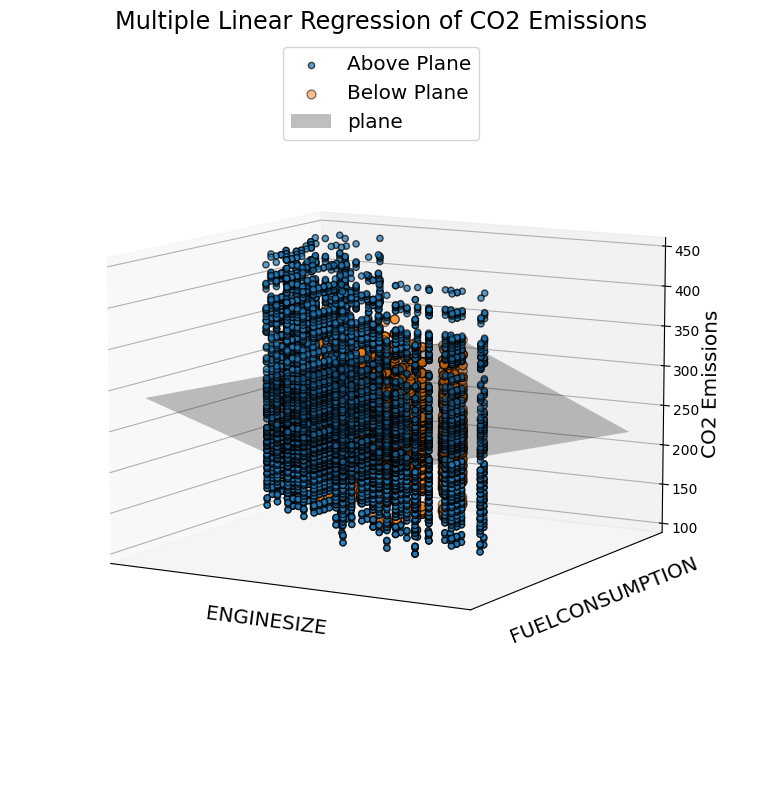

In [67]:
import numpy as np 
import matplotlib.pyplot as plt

X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zero_like(X1)

X1_surf, X2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100),
                               np.linspace(X2.min(), X2.max(), 100))
Y_surf = intercept_ +  coef_[0,0] * X1_surf  +  coef_[0,1] * X2_surf
Y_pred = regressor.predict(X_test.reshape(-1, 1)) if X_test.ndim == 1 else regressor.predict(X_test)
above_plane = Y_test >= Y_pred 
below_plane = Y_test < Y_pred
above_plane = above_plane[:,0]
below_plane = below_plane[:,0]

fig = plt.figure(figsize=(20, 8))
aa = fig.add_subplot(111, projection='3d')

aa.scatter(X1[above_plane], X2[above_plane], Y_test[above_plane],  label="Above Plane",s=20,alpha=.7,ec='k')
aa.scatter(X1[below_plane], X2[below_plane], Y_test[below_plane],  label="Below Plane",s=40,alpha=.5,ec='k')

aa.plot_surface(X1_surf, X2_surf, Y_surf, color='k', alpha=0.25,label='plane')

aa.view_init(elev=10)

aa.legend(fontsize='x-large',loc='upper center')
aa.set_xticks([])
aa.set_yticks([])
#aa.set_zticks([])
aa.set_box_aspect(None, zoom=0.85)
aa.set_xlabel('ENGINESIZE', fontsize='x-large')
aa.set_ylabel('FUELCONSUMPTION', fontsize='x-large')
aa.set_zlabel('CO2 Emissions', fontsize='x-large')
aa.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')
plt.tight_layout()
plt.show()

In [70]:
import math
a = np.arange(0,50)
b = (4/3)*math.pi*a**3
aa = plt.figure().add_subplot(111, projection="3d")
A,B = np.meshgrid(a, b)
C = np.sqrt((4/3)*math.pi*a**3)
aa.plot_surface(A, B, C)
plt.show()


SyntaxError: invalid syntax (790937683.py, line 1)